### Customer Churn Prediction — Phase 1: EDA
### Telco Customer Churn Dataset
 
Steps:
  1. Load data & first look
  2. Churn rate analysis
  3. Churn by contract type & tenure
  4. Numeric feature distributions by churn
  5. Correlation heatmap

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5", "grid.linewidth": 0.6})
 
COLORS = {"No": "#4C72B0", "Yes": "#E07070"}

### LOAD DATA

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
 
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"\nFirst 5 rows (key columns):")
print(df[["customerID","tenure","MonthlyCharges","Contract","Churn"]].head().to_string(index=False))
 
# TotalCharges is stored as string — whitespace entries are new customers
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
n_fixed = df["TotalCharges"].isnull().sum()
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print(f"\nTotalCharges: {n_fixed} whitespace entries → filled with 0 (tenure=0 customers)")
 
df["ChurnBinary"] = (df["Churn"] == "Yes").astype(int)
 
print(f"\nNumerical summary:")
print(df[["tenure","MonthlyCharges","TotalCharges"]].describe().round(2).to_string())

DATASET OVERVIEW
Shape          : 7,043 rows × 21 columns
Missing values : 0

First 5 rows (key columns):
customerID  tenure  MonthlyCharges       Contract Churn
7590-VHVEG       1           29.85 Month-to-month    No
5575-GNVDE      34           56.95       One year    No
3668-QPYBK       2           53.85 Month-to-month   Yes
7795-CFOCW      45           42.30       One year    No
9237-HQITU       2           70.70 Month-to-month   Yes

TotalCharges: 11 whitespace entries → filled with 0 (tenure=0 customers)

Numerical summary:
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80


### CHURN RATE


CHURN RATE
  Retained : 5,174  (73.5%)
  Churned  : 1,869  (26.5%)

  A model predicting 'no churn' for everyone scores 73.5% accuracy — useless.
  Use AUC-ROC and F1 instead.


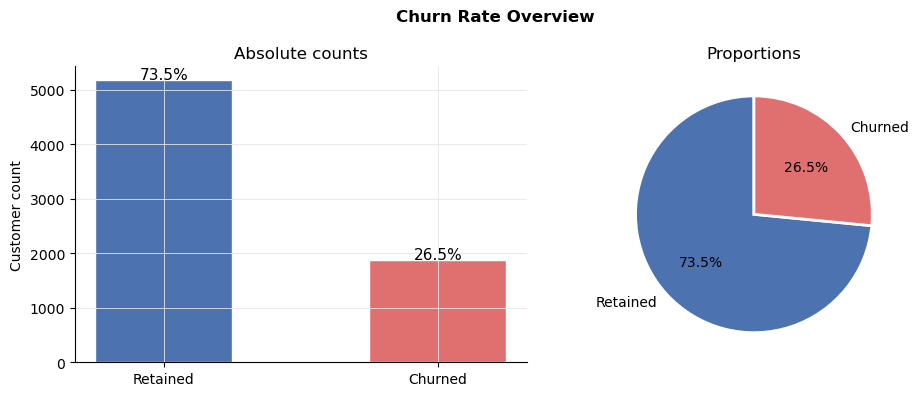

In [3]:
counts = df["Churn"].value_counts()
pcts   = df["Churn"].value_counts(normalize=True) * 100
 
print(f"\n{'='*60}\nCHURN RATE\n{'='*60}")
print(f"  Retained : {counts['No']:,}  ({pcts['No']:.1f}%)")
print(f"  Churned  : {counts['Yes']:,}  ({pcts['Yes']:.1f}%)")
print(f"\n  A model predicting 'no churn' for everyone scores "
      f"{pcts['No']:.1f}% accuracy — useless.")
print(f"  Use AUC-ROC and F1 instead.")
 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Churn Rate Overview", fontweight="bold")
 
ax = axes[0]
bars = ax.bar(["Retained","Churned"], counts.values,
              color=[COLORS["No"],COLORS["Yes"]], width=0.5, edgecolor="white")
ax.set_ylabel("Customer count")
ax.set_title("Absolute counts")
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f"{pct:.1f}%", ha="center", fontsize=11)
 
ax2 = axes[1]
ax2.pie(counts.values, labels=["Retained","Churned"],
        colors=[COLORS["No"],COLORS["Yes"]], autopct="%1.1f%%",
        startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
ax2.set_title("Proportions")
ax2.grid(False)
 
plt.tight_layout()
plt.savefig("phase1_churn_rate.png", dpi=150, bbox_inches="tight")
plt.show()
 

###  CHURN BY CONTRACT TYPE


CHURN BY CONTRACT TYPE
                ChurnRate  Count
Contract                        
Month-to-month       42.7   3875
One year             11.3   1473
Two year              2.8   1695


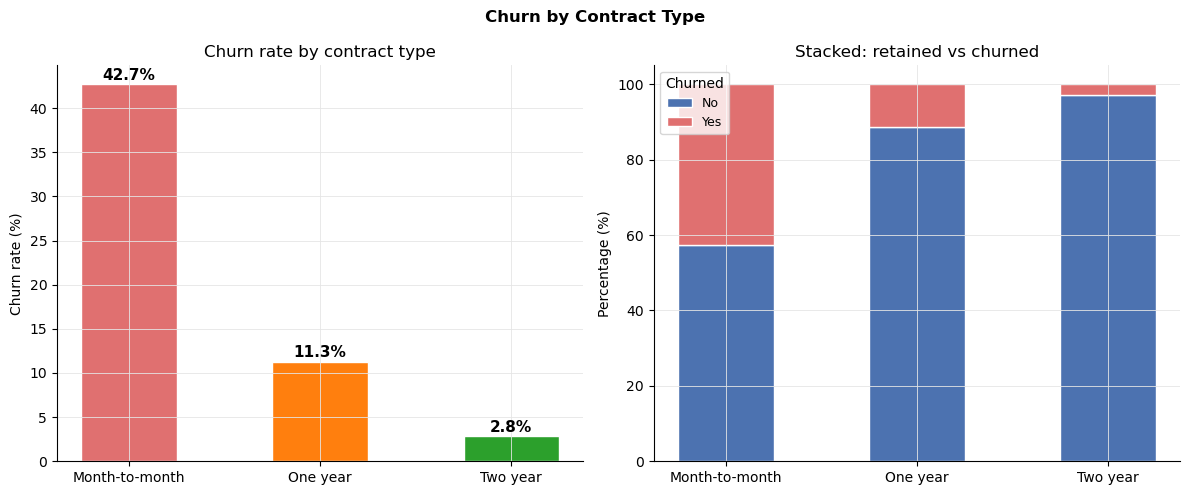

In [4]:
contract_churn = (df.groupby("Contract")["ChurnBinary"]
                    .agg(["mean","count"])
                    .rename(columns={"mean":"ChurnRate","count":"Count"})
                    .sort_values("ChurnRate", ascending=False))
contract_churn["ChurnRate"] *= 100
 
print(f"\n{'='*60}\nCHURN BY CONTRACT TYPE\n{'='*60}")
print(contract_churn.round(1).to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Churn by Contract Type", fontweight="bold")
 
ax = axes[0]
bars = ax.bar(contract_churn.index, contract_churn["ChurnRate"],
              color=["#E07070","#FF7F0E","#2ca02c"],
              width=0.5, edgecolor="white")
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn rate by contract type")
for bar, v in zip(bars, contract_churn["ChurnRate"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
 
ax2 = axes[1]
ct = pd.crosstab(df["Contract"], df["Churn"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(ct_pct))
for churn_val, color in zip(["No","Yes"], [COLORS["No"],COLORS["Yes"]]):
    ax2.bar(ct_pct.index, ct_pct[churn_val], bottom=bottom,
            color=color, label=churn_val, edgecolor="white", width=0.5)
    bottom += ct_pct[churn_val].values
ax2.set_ylabel("Percentage (%)")
ax2.set_title("Stacked: retained vs churned")
ax2.legend(title="Churned", fontsize=9)
 
plt.tight_layout()
plt.savefig("phase1_churn_by_contract.png", dpi=150, bbox_inches="tight")
plt.show()

### CHURN BY TENURE


CHURN BY TENURE BAND
            ChurnRate  Count
TenureBand                  
0-6m             53.3   1470
7-12m            35.9    705
1-2yr            28.7   1024
2-4yr            20.4   1594
4-6yr             9.5   2239


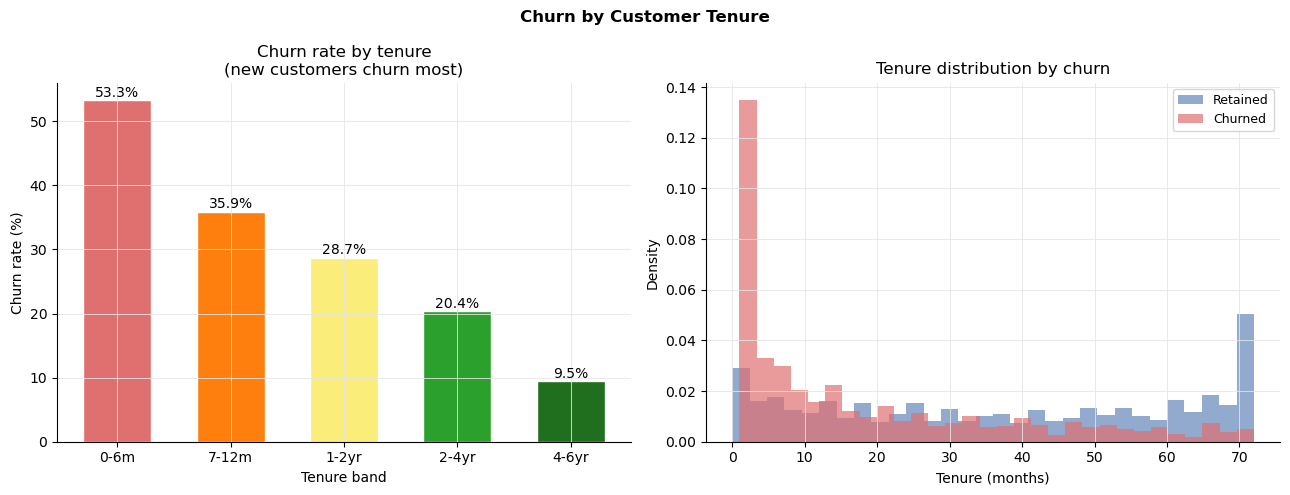

In [5]:
df["TenureBand"] = pd.cut(df["tenure"], bins=[0,6,12,24,48,72],
                           labels=["0-6m","7-12m","1-2yr","2-4yr","4-6yr"])
 
tenure_churn = (df.groupby("TenureBand", observed=True)["ChurnBinary"]
                  .agg(["mean","count"])
                  .rename(columns={"mean":"ChurnRate","count":"Count"}))
tenure_churn["ChurnRate"] *= 100
 
print(f"\n{'='*60}\nCHURN BY TENURE BAND\n{'='*60}")
print(tenure_churn.round(1).to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Churn by Customer Tenure", fontweight="bold")
 
ax = axes[0]
bar_colors = ["#E07070","#FF7F0E","#FAED7A","#2ca02c","#1F6F1F"]
bars = ax.bar(tenure_churn.index, tenure_churn["ChurnRate"],
              color=bar_colors, width=0.6, edgecolor="white")
ax.set_xlabel("Tenure band")
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn rate by tenure\n(new customers churn most)")
for bar, v in zip(bars, tenure_churn["ChurnRate"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{v:.1f}%", ha="center", fontsize=10)
 
ax2 = axes[1]
ax2.hist(df.loc[df["Churn"]=="No","tenure"], bins=30, alpha=0.6,
         color=COLORS["No"], label="Retained", density=True, edgecolor="none")
ax2.hist(df.loc[df["Churn"]=="Yes","tenure"], bins=30, alpha=0.7,
         color=COLORS["Yes"], label="Churned", density=True, edgecolor="none")
ax2.set_xlabel("Tenure (months)")
ax2.set_ylabel("Density")
ax2.set_title("Tenure distribution by churn")
ax2.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("phase1_churn_by_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

### NUMERIC FEATURES — VIOLIN PLOTS

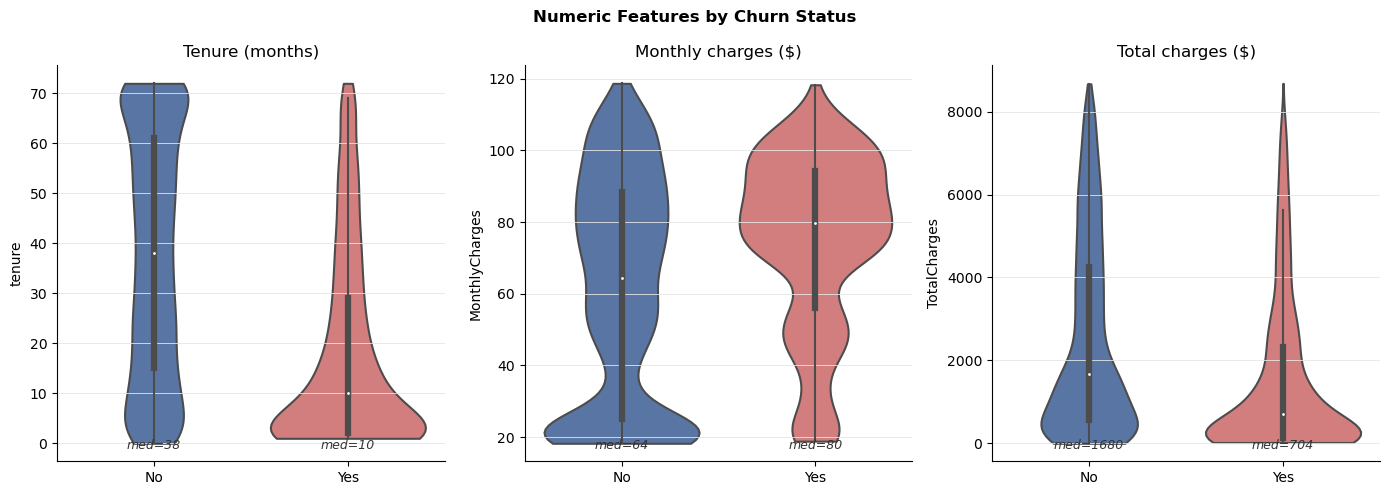


Numeric medians by churn:
  Tenure (months)         Retained=38  Churned=10  diff=-28
  Monthly charges ($)     Retained=64  Churned=80  diff=+15
  Total charges ($)       Retained=1680  Churned=704  diff=-976


In [6]:
NUMERIC = ["tenure","MonthlyCharges","TotalCharges"]
LABELS  = {"tenure":"Tenure (months)",
           "MonthlyCharges":"Monthly charges ($)",
           "TotalCharges":"Total charges ($)"}
 
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Numeric Features by Churn Status", fontweight="bold")
 
for ax, feat in zip(axes, NUMERIC):
    sns.violinplot(data=df, x="Churn", y=feat,
                   palette={"No":COLORS["No"],"Yes":COLORS["Yes"]},
                   order=["No","Yes"], inner="box", cut=0, ax=ax)
    ax.set_title(LABELS[feat])
    ax.set_xlabel("")
    for j, churn_val in enumerate(["No","Yes"]):
        med = df.loc[df["Churn"]==churn_val, feat].median()
        ax.text(j, ax.get_ylim()[0]+(ax.get_ylim()[1]-ax.get_ylim()[0])*0.03,
                f"med={med:.0f}", ha="center", fontsize=9,
                style="italic", color="#333")
 
plt.tight_layout()
plt.savefig("phase1_numeric_violins.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"\nNumeric medians by churn:")
for feat in NUMERIC:
    m0 = df.loc[df["Churn"]=="No",  feat].median()
    m1 = df.loc[df["Churn"]=="Yes", feat].median()
    print(f"  {LABELS[feat]:<22}  Retained={m0:.0f}  Churned={m1:.0f}  diff={m1-m0:+.0f}")

### CORRELATION HEATMAP


CORRELATIONS WITH CHURN

Top 5 negative (lower value → more likely to churn):
tenure         -0.352
TotalCharges   -0.198
Dependents     -0.164
Partner        -0.150
gender         -0.009

Top 5 positive (higher value → more likely to churn):
PhoneService        0.012
SeniorCitizen       0.151
PaperlessBilling    0.192
MonthlyCharges      0.193
Churn               1.000


c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


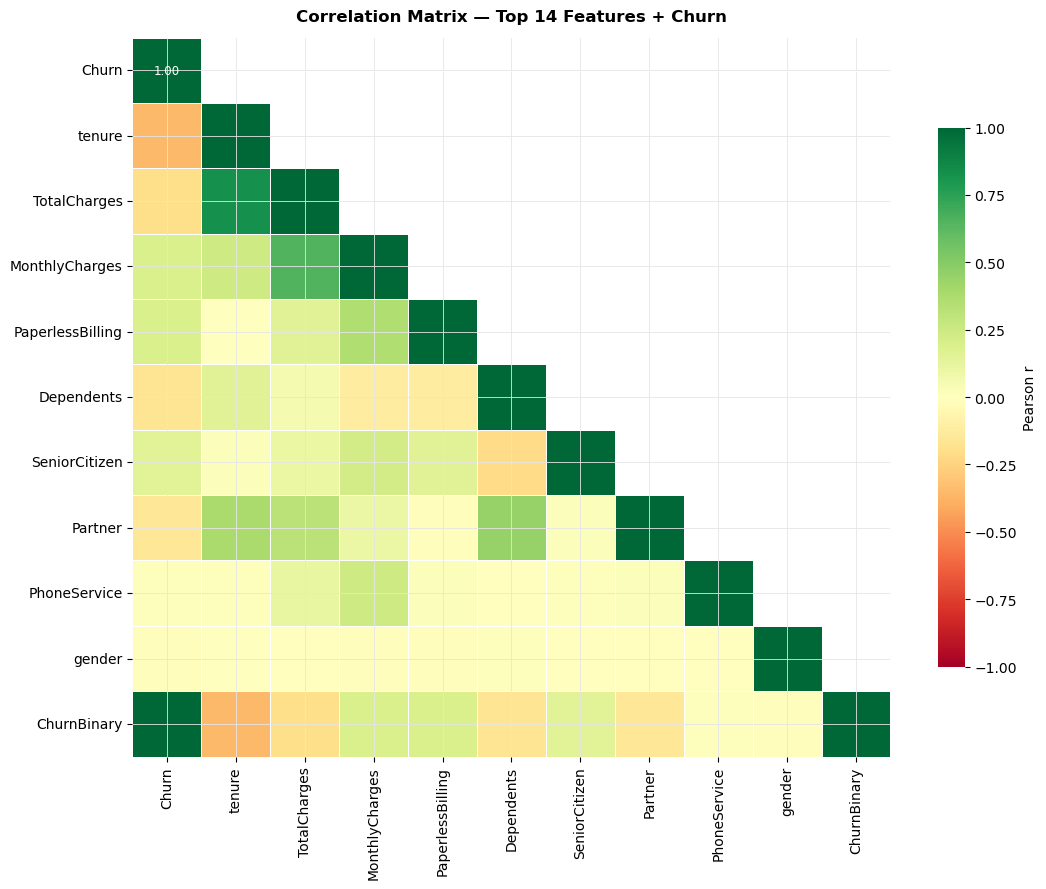

In [7]:
encode_map = {"Yes":1,"No":0,"Male":1,"Female":0}
df_enc = df.copy()
for col in df.select_dtypes("object").columns:
    if df[col].nunique() == 2:
        df_enc[col] = df_enc[col].map(encode_map).fillna(df_enc[col])
 
df_enc = pd.get_dummies(df_enc,
                         columns=["InternetService","Contract","PaymentMethod"],
                         drop_first=True)
 
num_cols = [c for c in df_enc.select_dtypes(include=np.number).columns
            if c not in ["customerID"]]
 
corr = df_enc[num_cols].corr()
target_corr = corr["ChurnBinary"].drop("ChurnBinary").sort_values()
 
print(f"\n{'='*60}\nCORRELATIONS WITH CHURN\n{'='*60}")
print(f"\nTop 5 negative (lower value → more likely to churn):")
print(target_corr.head(5).round(3).to_string())
print(f"\nTop 5 positive (higher value → more likely to churn):")
print(target_corr.tail(5).round(3).to_string())
 
top_feats = target_corr.abs().nlargest(14).index.tolist() + ["ChurnBinary"]
corr_sub  = df_enc[top_feats].corr()
mask_sub  = np.triu(np.ones_like(corr_sub, dtype=bool), k=1)
 
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_sub, mask=mask_sub, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor="white",
            annot_kws={"size":8.5}, ax=ax,
            cbar_kws={"shrink":0.75,"label":"Pearson r"})
ax.set_title("Correlation Matrix — Top 14 Features + Churn",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("phase1_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# SAVE & SUMMARY

df.to_csv("telco_clean.csv", index=False)
 
print(f"\n{'='*60}\nPHASE 1 SUMMARY\n{'='*60}")
print(f"  Customers           : {len(df):,}")
print(f"  Churn rate          : {pcts['Yes']:.1f}%")
print(f"  TotalCharges fixed  : {n_fixed} entries")
print(f"  Month-to-month churn: {contract_churn.loc['Month-to-month','ChurnRate']:.1f}%")
print(f"  Two-year churn      : {contract_churn.loc['Two year','ChurnRate']:.1f}%")
print(f"  0-6m tenure churn   : {tenure_churn.loc['0-6m','ChurnRate']:.1f}%")
print(f"  Top predictors      : {target_corr.abs().nlargest(3).index.tolist()}")
 
print("\nSaved:")
print("  phase1_churn_rate.png")
print("  phase1_churn_by_contract.png")
print("  phase1_churn_by_tenure.png")
print("  phase1_numeric_violins.png")
print("  phase1_correlation_heatmap.png")
print("  telco_clean.csv")
print("\nNext: Phase 2 — preprocessing pipeline + model comparison")
 


PHASE 1 SUMMARY
  Customers           : 7,043
  Churn rate          : 26.5%
  TotalCharges fixed  : 11 entries
  Month-to-month churn: 42.7%
  Two-year churn      : 2.8%
  0-6m tenure churn   : 53.3%
  Top predictors      : ['Churn', 'tenure', 'TotalCharges']

Saved:
  phase1_churn_rate.png
  phase1_churn_by_contract.png
  phase1_churn_by_tenure.png
  phase1_numeric_violins.png
  phase1_correlation_heatmap.png
  telco_clean.csv

Next: Phase 2 — preprocessing pipeline + model comparison
